# multiple linear regression

In [3]:
from sklearn.datasets import make_regression # for creating data by itself
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px # for drawing multiple dimensional data
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [4]:
x,y = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)
# n_featuress -> how many feature affect y
# higher_noise -> data is scatter too randomly

In [5]:
x.shape

(100, 2)

In [6]:
y.shape

(100,)

In [9]:
data = pd.DataFrame({'feature1':x[:,0],'feature2':x[:,1],'target':y})

In [20]:
data.head()

,feature1,feature2,target
0,0.821964,-0.126567,-21.854602
1,-2.416669,-0.239347,-97.619083
2,-0.593758,-1.040877,-40.295568
3,2.042516,-0.181722,79.255724
4,0.022726,-0.940239,94.877986


In [21]:
x = data[['feature1','feature2']]
y = data[['target']]

In [22]:
x.shape

(100, 2)

In [24]:
x.head()

,feature1,feature2
0,0.821964,-0.126567
1,-2.416669,-0.239347
2,-0.593758,-1.040877
3,2.042516,-0.181722
4,0.022726,-0.940239


In [23]:
y.shape

(100, 1)

In [25]:
y.head()

,target
0,-21.854602
1,-97.619083
2,-40.295568
3,79.255724
4,94.877986


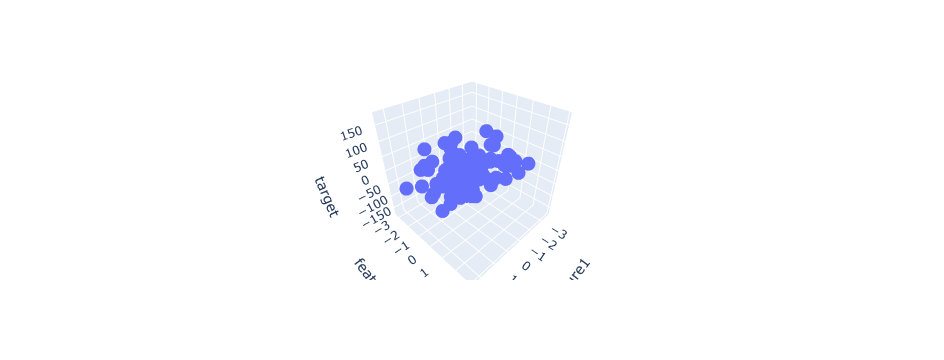

In [11]:
fig = px.scatter_3d(data,x='feature1',y='feature2',z='target')
fig.show()

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [27]:
x_train.shape

(70, 2)

In [28]:
x_train.head()

,feature1,feature2
11,2.050262,-0.253585
47,-0.188001,0.396375
85,-0.292845,-1.383445
28,1.867681,0.381343
93,-1.339501,-0.112743


In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
lr = LinearRegression()

In [32]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
y_pred = lr.predict(x_test)

In [39]:
y_pred

array([[ -2.74265706],
       [ 28.73699768],
       [  2.70362619],
       [-54.72594949],
       [ 36.83781365],
       [ -2.24564709],
       [-72.58752221],
       [ 66.16376667],
       [ 99.84628983],
       [ 26.50988111],
       [-33.05669446],
       [ 46.23354586],
       [-42.47601791],
       [-19.61738794],
       [-41.10049733],
       [-22.12969001],
       [ 23.03130832],
       [-57.36780777],
       [ 39.31295894],
       [-10.64362205],
       [-65.26384297],
       [-39.49839759],
       [ -3.08828777],
       [ -0.77038793],
       [ 35.90542779],
       [ -4.49434353],
       [ 74.84970846],
       [ 11.03150586],
       [108.04639861],
       [ 57.26351427]])

In [40]:
y_pred

array([[ -2.74265706],
       [ 28.73699768],
       [  2.70362619],
       [-54.72594949],
       [ 36.83781365],
       [ -2.24564709],
       [-72.58752221],
       [ 66.16376667],
       [ 99.84628983],
       [ 26.50988111],
       [-33.05669446],
       [ 46.23354586],
       [-42.47601791],
       [-19.61738794],
       [-41.10049733],
       [-22.12969001],
       [ 23.03130832],
       [-57.36780777],
       [ 39.31295894],
       [-10.64362205],
       [-65.26384297],
       [-39.49839759],
       [ -3.08828777],
       [ -0.77038793],
       [ 35.90542779],
       [ -4.49434353],
       [ 74.84970846],
       [ 11.03150586],
       [108.04639861],
       [ 57.26351427]])

In [43]:
print('MSE : ',mean_squared_error(y_test,y_pred))
print('MAE : ',mean_absolute_error(y_test,y_pred))
print('r2 score : ',r2_score(y_test,y_pred))

MSE :  2857.020210068467
MAE :  42.79226272825595
r2 score :  0.5569733638552266


In [46]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T  # ✅ create first

z_final = lr.predict(final).reshape(10,10)   # ✅ then use
z = z_final

C:\Users\dspri\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


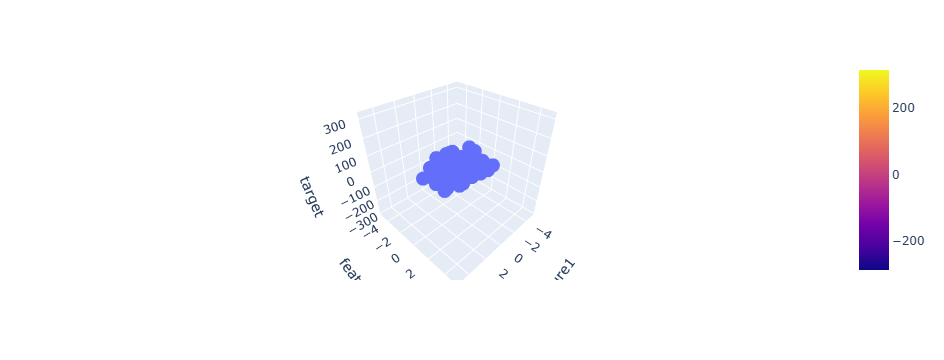

In [48]:
fig = px.scatter_3d(data, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [49]:
lr.coef_  # slope for feature1 and feature 2

array([[21.71800434, 38.44511427]])

In [50]:
lr.intercept_

array([13.52433422])